# **Weather Analysis**

**About dataset**

This dataset contains synthetic weather data generated for ten different locations, including New York, Los Angeles, Chicago, Houston, Phoenix, Philadelphia, San Antonio, San Diego, Dallas, and San Jose. The data includes information about temperature, humidity, precipitation, and wind speed, with 1 million data points generated for each parameter.

**Features:**

* Location: The city where the weather data was simulated.
* Date_Time: The date and time when the weather data was recorded.
* Temperature_C: The temperature in Celsius at the given location and time.
* Humidity_pct: The humidity in percentage at the given location and time.
* Precipitation_mm: The precipitation in millimeters at the given location and time.
* Wind_Speed_kmh: The wind speed in kilometers per hour at the given location and time.

**Objective**

Analyze weather data to discover trends in temperature, humidity, precipitation, and wind speed.

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

In [106]:
data = pd.read_csv('weather_data.csv') #load dataset and displayed the first 10 rows
data.head(10)

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622
5,San Diego,2024-01-21 08:54:56,27.341055,49.023236,9.166543,27.473896
6,San Jose,2024-01-13 02:10:54,1.881883,65.742325,0.221709,1.073112
7,New York,2024-01-25 19:04:34,-6.894766,30.804894,8.027624,16.848337
8,New York,2024-03-29 05:20:30,0.963545,38.819158,3.640129,7.989024
9,San Jose,2024-05-18 09:14:02,-1.607088,82.198701,4.101493,25.647282


In [107]:
data.rename(columns={
    "Location": "Location",
    "Date_Time": "Date",
    "Temperature_C": "Temperature",
    "Humidity_pct": "Humidity",
    "Precipitation_mm": "Precipitation",
    "Wind_Speed_kmh": "WindSpeed"
}, inplace=True)

data.head() # changed the column name

,Location,Date,Temperature,Humidity,Precipitation,WindSpeed
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622


In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Location       1000000 non-null  object 
 1   Date           1000000 non-null  object 
 2   Temperature    1000000 non-null  float64
 3   Humidity       1000000 non-null  float64
 4   Precipitation  1000000 non-null  float64
 5   WindSpeed      1000000 non-null  float64
dtypes: float64(4), object(2)
memory usage: 45.8+ MB


In [109]:
data.describe()

,Temperature,Humidity,Precipitation,WindSpeed
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,14.779705,60.021830,5.109639,14.997598
std,14.482558,17.324022,2.947997,8.663556
min,-19.969311,30.000009,0.000009,0.000051
25%,2.269631,45.008500,2.580694,7.490101
50%,14.778002,60.018708,5.109917,14.993777
75%,27.270489,75.043818,7.613750,22.514110
max,39.999801,89.999977,14.971583,29.999973


**Data cleaning:**

In [110]:
data.isnull().sum() # no empty values

,0
Location,0
Date,0
Temperature,0
Humidity,0
Precipitation,0
WindSpeed,0


In [111]:
data.duplicated().sum() # no duplicate values

np.int64(0)

In [112]:
data.dtypes

,0
Location,object
Date,object
Temperature,float64
Humidity,float64
Precipitation,float64
WindSpeed,float64


In [113]:
data["Date"] = pd.to_datetime(data["Date"]) # changed the data type of 'date' from object to date format

In [114]:
data

,Location,Date,Temperature,Humidity,Precipitation,WindSpeed
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622
...,...,...,...,...,...,...
999995,Dallas,2024-01-01 20:29:48,23.416877,37.705024,3.819833,16.538119
999996,San Antonio,2024-01-20 15:59:48,6.759080,40.731036,8.182785,29.005558
999997,New York,2024-04-14 08:30:09,15.664465,62.201884,3.987558,0.403909
999998,Chicago,2024-05-12 20:10:43,18.999994,63.703245,4.294325,6.326036


**Data Exploring:**

In [115]:
print(data["Temperature"].mean())

14.779704927041756


In [116]:
 data["Humidity"].max()

89.99997706846489

In [117]:
data.groupby("Location")["Temperature"].mean()

,Temperature
Location,
Chicago,15.009208
Dallas,15.009097
Houston,14.942985
Los Angeles,15.081063
New York,15.013389
Philadelphia,15.035892
Phoenix,12.792479
San Antonio,15.027761
San Diego,14.933539


In [118]:
highest_temp = data.loc[data["Temperature"].idxmax()] # Find the single highest temperature and its location

print(highest_temp)

Location                    New York
Date             2024-05-16 14:31:50
Temperature                39.999801
Humidity                   35.418345
Precipitation               6.574819
WindSpeed                  20.988972
Name: 899115, dtype: object


In [119]:
highest_temp_by_location = data.groupby("Location")["Temperature"].max() #Find the highest temperature recorded in each location

print(highest_temp_by_location)

Location
Chicago         39.998561
Dallas          39.998804
Houston         39.998913
Los Angeles     39.999592
New York        39.999801
Philadelphia    39.999642
Phoenix         39.998889
San Antonio     39.998343
San Diego       39.999692
San Jose        39.999015
Name: Temperature, dtype: float64


**Visualization:**

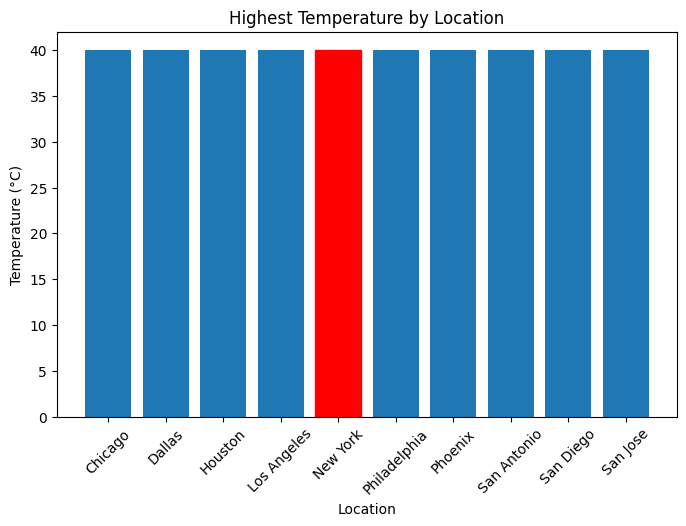

In [120]:
highest_temp = data.groupby("Location")["Temperature"].max()

plt.figure(figsize=(8,5))
bars = plt.bar(highest_temp.index, highest_temp.values)

# Highlight the highest temperature bar
max_index = highest_temp.values.argmax()
bars[max_index].set_color("red")

plt.title("Highest Temperature by Location")
plt.xlabel("Location")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)

plt.show()

* Every city in the dataset reached a maximum temperature close to 40C
* This suggests that all cities experienced similarly high peak temperatures during the observed period.
* New York is highlighted in red to emphasize its maximum temperature

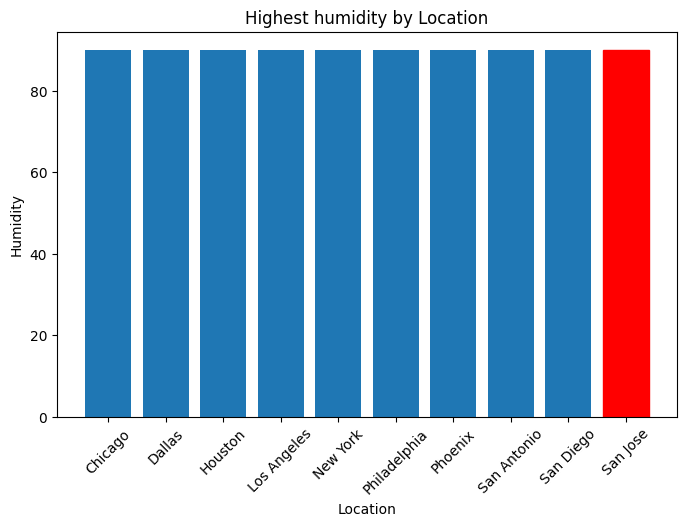

In [121]:
highest_humid = data.groupby("Location")["Humidity"].max()

plt.figure(figsize=(8,5))
bars = plt.bar(highest_humid.index, highest_humid.values)

# Highlight the highest temperature bar
max_index = highest_humid.values.argmax()
bars[max_index].set_color("red")

plt.title("Highest humidity by Location")
plt.xlabel("Location")
plt.ylabel("Humidity")
plt.xticks(rotation=45)

plt.show()

* The chart shows that every city reached a peak humidity level close to 90%, indicating consistently high humidity across the dataset
* San Jose is highlighted in red
* Since all bars are almost equal in height, the highest humidity values are similar across all cities.

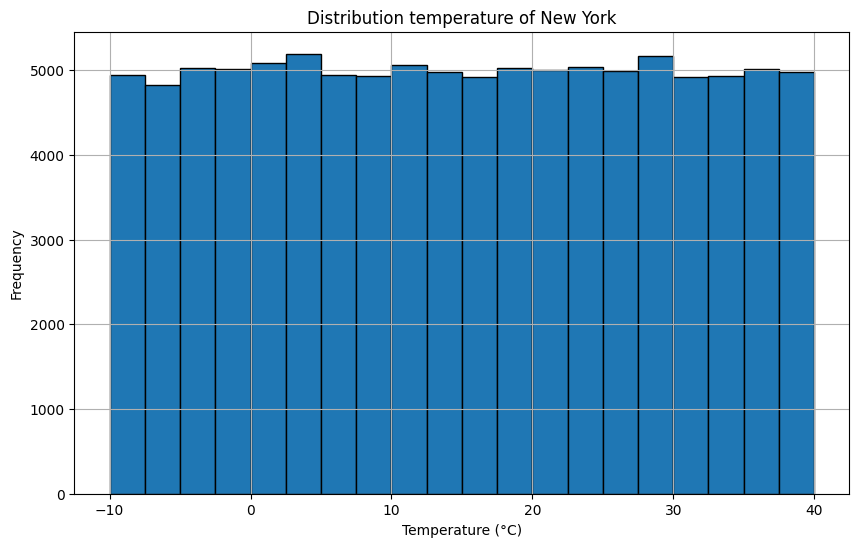

In [122]:
plt.figure(figsize=(10, 6))
plt.hist(data[data['Location'] == 'New York']['Temperature'], bins=20, edgecolor='black')
plt.title('Distribution temperature of New York')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

* The histogram shows temperatures ranging from approximately -10°C to 40°C, indicating that the dataset includes both cold and hot weather conditions.
* The bars have similar heights across the temperature range, meaning that temperatures are distributed evenly rather than being concentrated around a specific value.
